# Unit13 參數估計 | Parameter Estimation

本 Notebook 示範如何以 Python（SciPy）進行**參數估計**，涵蓋線性最小平方法、非線性參數估計及置信區間計算，並結合化工實際問題加以應用。

## 學習目標
- 推導並實作線性最小平方法矩陣解 $\boldsymbol{\theta} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{Y}$
- 使用 `scipy.linalg.lstsq()` 求解線性參數估計問題
- 識別並處理可線性化之非線性模式（取對數或變數代換）
- 使用 `scipy.optimize.curve_fit()` 求解非線性模式並獲取協方差矩陣
- 使用 `scipy.optimize.least_squares()` 進行含上下限之有界非線性參數估計
- 由協方差矩陣 `pcov` 推算各參數之 95% 置信區間

---
### 0. 環境設定

In [22]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit13_Parameter_Estimation'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit13'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit13
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit13\outputs\Unit13_Parameter_Estimation
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit13\outputs\Unit13_Parameter_Estimation\figs


---
### 1. 載入套件

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.linalg import lstsq
from scipy.optimize import curve_fit, least_squares

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

print("✓ 套件載入完成")
print(f"  numpy  版本: {np.__version__}")
import scipy
print(f"  scipy  版本: {scipy.__version__}")
import matplotlib
print(f"  matplotlib 版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy  版本: 1.23.5
  scipy  版本: 1.15.2
  matplotlib 版本: 3.10.8


---
## 2. 線性模式之最小平方法（7.1.1）

### 2.1 最小平方法矩陣型式推導

對於線性參數模式 $\mathbf{Y}^M = \mathbf{X}\boldsymbol{\theta}$ ，最小化誤差平方和目標函數：

$$
J(\boldsymbol{\theta}) = (\mathbf{Y} - \mathbf{X}\boldsymbol{\theta})^T(\mathbf{Y} - \mathbf{X}\boldsymbol{\theta})
$$

令 $\dfrac{\partial J}{\partial \boldsymbol{\theta}} = 0$ ，得解析解：

$$
\boldsymbol{\theta} = \left(\mathbf{X}^T\mathbf{X}\right)^{-1}\mathbf{X}^T\mathbf{Y}
$$

以下用 NumPy 手動實作，並與 `scipy.linalg.lstsq()` 結果比對。

In [24]:
# ============================================================
# 範例 7-1-1: 線性模式 y = a + b*exp(3x) + c*exp(-3x) 之參數估計
# 實驗數據 (ch7 範例 7-1-1)
# ============================================================
x = np.array([0.5, 1.0, 2.0, 3.0])
y = np.array([1.0, 2.0, 2.0, 1.0])

# ── Step 1: 建構設計矩陣 X ──────────────────────────────────
# 模式: y = a*1 + b*exp(3x) + c*exp(-3x)
# 設計矩陣各行: [1, exp(3x), exp(-3x)]
X = np.column_stack([np.ones(len(x)), np.exp(3*x), np.exp(-3*x)])
Y = y.reshape(-1, 1)

print("設計矩陣 X:")
print(X)
print(f"\n量測值向量 Y = {Y.flatten()}")

# ── Step 2: 手動計算 (X^T X)^{-1} X^T Y ──────────────────
theta_manual = np.linalg.inv(X.T @ X) @ X.T @ Y
print(f"\n方法一 (手動矩陣運算): theta = {theta_manual.flatten()}")
print(f"  a = {theta_manual[0,0]:.4f},  b = {theta_manual[1,0]:.6f},  c = {theta_manual[2,0]:.4f}")

# ── Step 3: 使用 scipy.linalg.lstsq() ─────────────────────
theta_lstsq, res, rank, sv = lstsq(X, y)
print(f"\n方法二 (scipy.linalg.lstsq): theta = {theta_lstsq}")
print(f"  a = {theta_lstsq[0]:.4f},  b = {theta_lstsq[1]:.6f},  c = {theta_lstsq[2]:.4f}")
print(f"\n設計矩陣秩 rank = {rank}  (滿秩: {rank == X.shape[1]})")

# ── Step 4: 計算殘差與目標函數 J ──────────────────────────
y_model_1 = X @ theta_lstsq
J1 = np.sum((y - y_model_1)**2)
print(f"\n目標函數 J = {J1:.6f}")
print("各點誤差:", (y - y_model_1).round(6))

設計矩陣 X:
[[1.00000000e+00 4.48168907e+00 2.23130160e-01]
 [1.00000000e+00 2.00855369e+01 4.97870684e-02]
 [1.00000000e+00 4.03428793e+02 2.47875218e-03]
 [1.00000000e+00 8.10308393e+03 1.23409804e-04]]

量測值向量 Y = [1. 2. 2. 1.]

方法一 (手動矩陣運算): theta = [ 2.15386898e+00 -1.42806143e-04 -5.07109610e+00]
  a = 2.1539,  b = -0.000143,  c = -5.0711

方法二 (scipy.linalg.lstsq): theta = [ 2.15386898e+00 -1.42806143e-04 -5.07109610e+00]
  a = 2.1539,  b = -0.000143,  c = -5.0711

設計矩陣秩 rank = 3  (滿秩: True)

目標函數 J = 0.017787
各點誤差: [-0.021714  0.101474 -0.083687  0.003927]


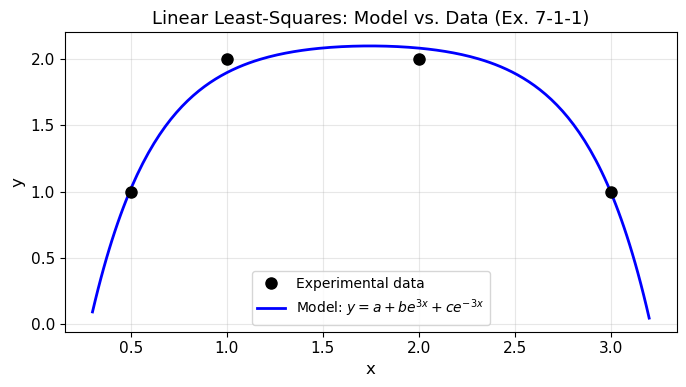

圖檔已儲存: d:\MyGit\ChemE-3502\Unit13\outputs\Unit13_Parameter_Estimation\figs\linear_model_711.png


In [25]:
# ── 繪圖: 實驗數據 vs 模式預測 ────────────────────────────
x_fine = np.linspace(0.3, 3.2, 200)
X_fine = np.column_stack([np.ones(len(x_fine)), np.exp(3*x_fine), np.exp(-3*x_fine)])
y_pred_1 = X_fine @ theta_lstsq

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, y, 'ko', markersize=8, label='Experimental data', zorder=5)
ax.plot(x_fine, y_pred_1, 'b-', label=r'Model: $y = a + be^{3x} + ce^{-3x}$')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Linear Least-Squares: Model vs. Data (Ex. 7-1-1)')
ax.legend()
plt.tight_layout()
fig.savefig(FIG_DIR / 'linear_model_711.png', dpi=120)
plt.show()
print(f"圖檔已儲存: {FIG_DIR / 'linear_model_711.png'}")

---
### 2.2 可線性化之非線性模式（範例 7-1-2）

模式 $y = axe^{-bx}$ 表面上為非線性，但兩側同除以 $x$ 再取自然對數可得：

$$
\ln(y/x) = \ln a - bx
$$

令 $\alpha = \ln a$ 為新參數，則此問題化為線性最小平方問題：

$$
\underbrace{\begin{bmatrix} \ln(y_1/x_1) \\ \vdots \\ \ln(y_n/x_n) \end{bmatrix}}_{\mathbf{B}} = \underbrace{\begin{bmatrix} 1 & -x_1 \\ \vdots & \vdots \\ 1 & -x_n \end{bmatrix}}_{\mathbf{A}} \begin{bmatrix} \alpha \\ b \end{bmatrix}
$$

求得 $\alpha, b$ 後，再反推 $a = e^{\alpha}$ 。

In [26]:
# ============================================================
# 範例 7-1-2: 可線性化模式 y = a*x*exp(-b*x)
# 相同數據，比較兩模式的目標函數 J
# ============================================================

# ── Step 1: 建構線性化後的設計矩陣 ──────────────────────────
# ln(y/x) = alpha - b*x  =>  B = A * [alpha, b]^T
B = np.log(y / x)             # 因變數 (變換後)
A = np.column_stack([np.ones(len(x)), -x])  # 設計矩陣

theta_lin, _, _, _ = lstsq(A, B)
alpha_est, b_est = theta_lin
a_est = np.exp(alpha_est)

print("可線性化非線性模式 y = a*x*exp(-b*x)")
print(f"  α = ln(a) = {alpha_est:.4f}")
print(f"  b         = {b_est:.4f}")
print(f"  a = exp(α) = {a_est:.4f}")

# ── Step 2: 計算原始空間中的誤差 ─────────────────────────
y_model_2 = a_est * x * np.exp(-b_est * x)
J2 = np.sum((y - y_model_2)**2)

print(f"\n各點模式預測值: {y_model_2.round(4)}")
print(f"各點誤差:        {(y - y_model_2).round(4)}")
print(f"目標函數 J      = {J2:.4f}")

# ── Step 3: 模式比較 ─────────────────────────────────────
print("\n" + "="*45)
print("模式比較（相同 4 組數據）")
print(f"  模式一: y = a + b*exp(3x) + c*exp(-3x)  J = {J1:.4f}")
print(f"  模式二: y = a*x*exp(-bx)                J = {J2:.4f}")
print("→ 模式一 J 值遠小於模式二，擬合效果更佳")

可線性化非線性模式 y = a*x*exp(-b*x)
  α = ln(a) = 1.2722
  b         = 0.7386
  a = exp(α) = 3.5685

各點模式預測值: [1.2333 1.705  1.6292 1.1676]
各點誤差:        [-0.2333  0.295   0.3708 -0.1676]
目標函數 J      = 0.3071

模式比較（相同 4 組數據）
  模式一: y = a + b*exp(3x) + c*exp(-3x)  J = 0.0178
  模式二: y = a*x*exp(-bx)                J = 0.3071
→ 模式一 J 值遠小於模式二，擬合效果更佳


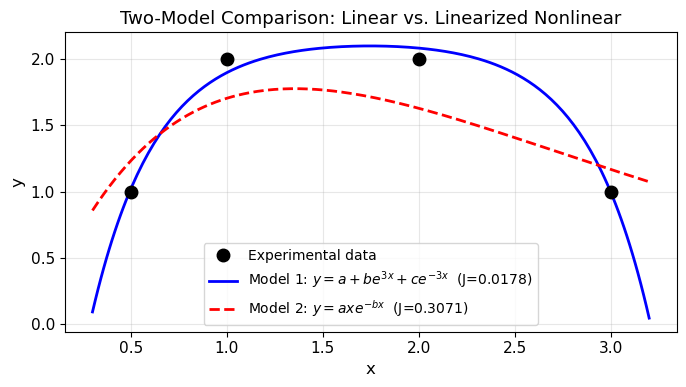

圖檔已儲存: d:\MyGit\ChemE-3502\Unit13\outputs\Unit13_Parameter_Estimation\figs\model_comparison.png


In [34]:
# ── 繪圖: 兩模式比較圖 ────────────────────────────────────
y_pred_2 = a_est * x_fine * np.exp(-b_est * x_fine)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, y, 'ko', markersize=9, label='Experimental data', zorder=5)
ax.plot(x_fine, y_pred_1, 'b-', label=rf'Model 1: $y=a+be^{{3x}}+ce^{{-3x}}$  (J={J1:.4f})')
ax.plot(x_fine, y_pred_2, 'r--', label=rf'Model 2: $y=axe^{{-bx}}$  (J={J2:.4f})')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Two-Model Comparison: Linear vs. Linearized Nonlinear')
ax.legend(loc='lower center')
plt.tight_layout()
fig.savefig(FIG_DIR / 'model_comparison.png', dpi=120)
plt.show()
print(f"圖檔已儲存: {FIG_DIR / 'model_comparison.png'}")

---
## 3. 非線性模式之參數估計法（7.1.2）

### 3.1 `scipy.optimize.curve_fit()` 示範（範例 7-1-3）

**問題**：給定 10 組 $(x_i, y_i)$ 實驗數據，估計非線性模式 $y = \alpha x^2 + \beta \sin(x) + \gamma x^3$ 中的參數 $\alpha, \beta, \gamma$ 。

`curve_fit()` 使用 **Levenberg-Marquardt（LM）演算法** 迭代求解，並返回：
- `popt`：最優參數向量 $[\alpha^*, \beta^*, \gamma^*]$
- `pcov`：參數估計值之**協方差矩陣**（用於計算置信區間）

```python
popt, pcov = curve_fit(model_func, xdata, ydata, p0=initial_guess)
```

In [28]:
# ============================================================
# 範例 7-1-3: 非線性模式 y = alpha*x^2 + beta*sin(x) + gamma*x^3
# 實驗數據 (ch7 範例 7-1-3)
# ============================================================

# 實驗數據
x_713 = np.array([3.6, 7.7, 9.3, 4.1, 8.6, 2.8, 1.3, 7.9, 10.0, 5.4])
y_713 = np.array([16.5, 150.6, 263.1, 24.7, 208.5, 9.9, 2.7, 163.9, 325.0, 54.3])

# ── 定義模式函數 ─────────────────────────────────────────
def model_713(x, alpha, beta, gamma):
    """非線性模式: y = alpha*x^2 + beta*sin(x) + gamma*x^3"""
    return alpha * x**2 + beta * np.sin(x) + gamma * x**3

# ── 參數起始猜測值（依物理先驗知識設為 0.5）─────────────
p0 = [0.5, 0.5, 0.5]

# ── 使用 curve_fit() 估計參數 ────────────────────────────
popt, pcov = curve_fit(model_713, x_713, y_713, p0=p0)
alpha_opt, beta_opt, gamma_opt = popt

print("非線性模式 y = α·x² + β·sin(x) + γ·x³")
print(f"\n參數估計值:")
print(f"  α (alpha) = {alpha_opt:.4f}")
print(f"  β (beta)  = {beta_opt:.4f}")
print(f"  γ (gamma) = {gamma_opt:.4f}")

# ── 計算目標函數 J ────────────────────────────────────────
y_pred_713 = model_713(x_713, *popt)
J_713 = np.sum((y_713 - y_pred_713)**2)
print(f"\n目標函數 J = {J_713:.4f}")

# ── 協方差矩陣 ───────────────────────────────────────────
print(f"\n協方差矩陣 pcov:")
print(pcov.round(6))

非線性模式 y = α·x² + β·sin(x) + γ·x³

參數估計值:
  α (alpha) = 0.2269
  β (beta)  = 0.3385
  γ (gamma) = 0.3022

目標函數 J = 6.2950

協方差矩陣 pcov:
[[ 1.56700e-03 -2.35900e-03 -1.73000e-04]
 [-2.35900e-03  1.80231e-01  2.06000e-04]
 [-1.73000e-04  2.06000e-04  1.90000e-05]]


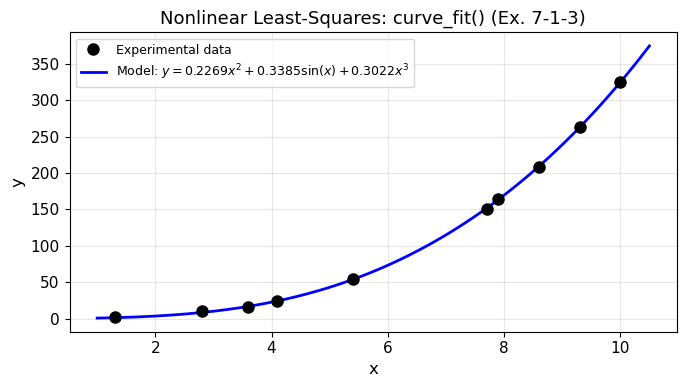

圖檔已儲存: d:\MyGit\ChemE-3502\Unit13\outputs\Unit13_Parameter_Estimation\figs\nonlinear_model_713.png


In [29]:
# ── 繪圖: 非線性模式預測 vs 實驗數據 ─────────────────────
x_fine_713 = np.linspace(1.0, 10.5, 300)
y_fine_713 = model_713(x_fine_713, *popt)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_713, y_713, 'ko', markersize=8, label='Experimental data', zorder=5)
ax.plot(x_fine_713, y_fine_713, 'b-',
        label=rf'Model: $y={alpha_opt:.4f}x^2+{beta_opt:.4f}\sin(x)+{gamma_opt:.4f}x^3$')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Nonlinear Least-Squares: curve_fit() (Ex. 7-1-3)')
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(FIG_DIR / 'nonlinear_model_713.png', dpi=120)
plt.show()
print(f"圖檔已儲存: {FIG_DIR / 'nonlinear_model_713.png'}")

---
### 3.2 含上下限之有界非線性參數估計（`scipy.optimize.least_squares()`）

**問題（改編自 ch7 範例 7-2-3）**：活性碳吸附等溫模式

$$
Q = \frac{bC}{1 + aC^{\beta}}
$$

其中 $Q$ 為吸附量，$C$ 為溶質濃度，$a, b, \beta$ 為待估參數。已知物理限制：
- $0 \leq a \leq 10$
- $100 \leq b \leq 200$  
- $0 \leq \beta \leq 1$

`least_squares()` 的殘差函數格式：`def residuals(p): return y_data - model(x_data, *p)`

In [30]:
# ============================================================
# 活性碳吸附等溫模式: Q = b*C / (1 + a*C^beta)
# 有界非線性最小平方估計 (改編自 ch7 範例 7-2-3)
# ============================================================

# 實驗數據 (16 組)
C_adsorb = np.array([0.01, 0.02, 0.03, 0.05, 0.07, 0.10, 0.15, 0.20,
                     0.30, 0.40, 0.50, 0.70, 1.00, 1.50, 2.00, 3.00])
Q_adsorb = np.array([1.5, 2.8, 3.8, 5.5, 7.0, 9.2, 12.0, 14.5,
                     18.2, 21.0, 23.5, 27.1, 31.0, 35.8, 39.2, 44.5])

# ── 定義模式函數與殘差函數 ───────────────────────────────
def model_adsorb(C, a, b, beta):
    """活性碳吸附等溫模式: Q = b*C / (1 + a*C^beta)"""
    return b * C / (1 + a * C**beta)

def residuals_adsorb(p):
    """殘差向量函數，格式: residuals(p) -> e = y - f(x, p)"""
    return Q_adsorb - model_adsorb(C_adsorb, *p)

# ── 上下限設定 ────────────────────────────────────────────
# 參數順序: [a, b, beta]
lb = [0.0,   100.0, 0.0]    # 下限
ub = [10.0,  200.0, 1.0]    # 上限
p0_adsorb = [4.0, 150.0, 0.8]  # 初始猜測值

# ── 方法一: least_squares() 有界估計 ─────────────────────
result = least_squares(residuals_adsorb, p0_adsorb, bounds=(lb, ub))
p_LS = result.x
J_LS = 2 * result.cost   # result.cost = J/2

print("有界非線性最小平方 (least_squares with bounds):")
print(f"  a    = {p_LS[0]:.4f}  [0, 10]")
print(f"  b    = {p_LS[1]:.4f}  [100, 200]")
print(f"  beta = {p_LS[2]:.4f}  [0, 1]")
print(f"  J    = {J_LS:.4f}")

# ── 方法二: curve_fit() 同界估計（取得 pcov 用）────────────
popt_cf, pcov_cf = curve_fit(model_adsorb, C_adsorb, Q_adsorb, p0=p0_adsorb,
                              bounds=(lb, ub), maxfev=5000)
J_cf = np.sum((Q_adsorb - model_adsorb(C_adsorb, *popt_cf))**2)

print("\ncurve_fit() (with bounds, for pcov):")
print(f"  a    = {popt_cf[0]:.4f}")
print(f"  b    = {popt_cf[1]:.4f}")
print(f"  beta = {popt_cf[2]:.4f}")
print(f"  J    = {J_cf:.4f}")

有界非線性最小平方 (least_squares with bounds):
  a    = 3.8466  [0, 10]
  b    = 150.5087  [100, 200]
  beta = 0.7904  [0, 1]
  J    = 0.2206

curve_fit() (with bounds, for pcov):
  a    = 3.8466
  b    = 150.5087
  beta = 0.7904
  J    = 0.2206


---
## 4. 參數估計值之置信區間（7.1.3）

### 4.1 由協方差矩陣推算 95% 置信區間

`scipy.optimize.curve_fit()` 返回的 `pcov` 為**參數估計值之協方差矩陣**。其對角線元素為各參數估計值的方差（Variance）：

$$
\sigma_{p_k} = \sqrt{[\mathbf{P}_{\text{cov}}]_{kk}}
$$

95% 置信區間（近似正態分布假設）：

$$
\hat{p}_k \pm 1.96 \cdot \sigma_{p_k}
$$

以下對**非線性模式** $y = \alpha x^2 + \beta\sin(x) + \gamma x^3$ （範例 7-1-3）及**吸附等溫模式**（範例 7-2-3）分別計算。

In [31]:
# ============================================================
# 4.1 非線性模式 (範例 7-1-3) 之 95% 置信區間
# ============================================================

# 從協方差矩陣提取各參數之標準差
perr_713 = np.sqrt(np.diag(pcov))
ci95_713 = 1.96 * perr_713

param_names = ['α (alpha)', 'β (beta)', 'γ (gamma)']
print("非線性模式 y = α·x² + β·sin(x) + γ·x³  之 95% 置信區間")
print("-" * 60)
print(f"{'參數':<12} {'估計值':>10} {'標準差':>10} {'95% CI 下限':>12} {'95% CI 上限':>12}")
print("-" * 60)
for name, p, err, ci in zip(param_names, popt, perr_713, ci95_713):
    print(f"{name:<12} {p:>10.4f} {err:>10.4f} {p-ci:>12.4f} {p+ci:>12.4f}")
print("-" * 60)
print("\n→ α 與 γ 的置信區間較窄（可辨識性佳）；β 的置信區間較寬，")
print("  表示 sin(x) 項對模式擬合的貢獻相對較不顯著。")

非線性模式 y = α·x² + β·sin(x) + γ·x³  之 95% 置信區間
------------------------------------------------------------
參數                  估計值        標準差    95% CI 下限    95% CI 上限
------------------------------------------------------------
α (alpha)        0.2269     0.0396       0.1493       0.3045
β (beta)         0.3385     0.4245      -0.4936       1.1706
γ (gamma)        0.3022     0.0044       0.2935       0.3108
------------------------------------------------------------

→ α 與 γ 的置信區間較窄（可辨識性佳）；β 的置信區間較寬，
  表示 sin(x) 項對模式擬合的貢獻相對較不顯著。


吸附等溫模式 Q = b·C / (1 + a·C^β)  之 95% 置信區間
------------------------------------------------------------
參數                  估計值        標準差    95% CI 下限    95% CI 上限
------------------------------------------------------------
a                3.8466     0.0985       3.6535       4.0398
b              150.5087     2.8896     144.8451     156.1723
beta (β)         0.7904     0.0054       0.7798       0.8011
------------------------------------------------------------


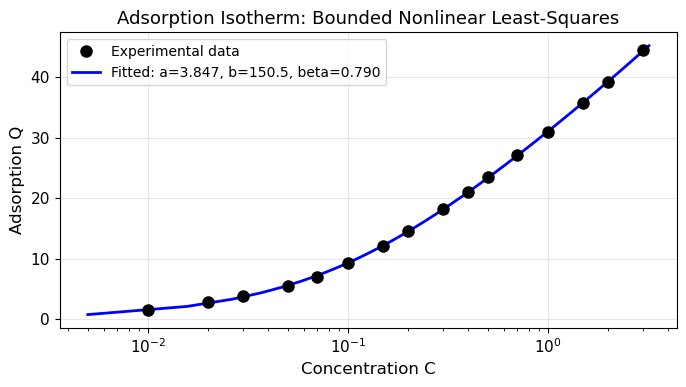


圖檔已儲存: d:\MyGit\ChemE-3502\Unit13\outputs\Unit13_Parameter_Estimation\figs\adsorption_isotherm.png


In [32]:
# ============================================================
# 4.2 吸附等溫模式 (範例 7-2-3) 之 95% 置信區間
# ============================================================

# 使用 curve_fit 返回的 pcov 計算置信區間
perr_adsorb = np.sqrt(np.diag(pcov_cf))
ci95_adsorb = 1.96 * perr_adsorb

param_names_adsorb = ['a', 'b', 'beta (β)']
print("吸附等溫模式 Q = b·C / (1 + a·C^β)  之 95% 置信區間")
print("-" * 60)
print(f"{'參數':<12} {'估計值':>10} {'標準差':>10} {'95% CI 下限':>12} {'95% CI 上限':>12}")
print("-" * 60)
for name, p, err, ci in zip(param_names_adsorb, popt_cf, perr_adsorb, ci95_adsorb):
    print(f"{name:<12} {p:>10.4f} {err:>10.4f} {p-ci:>12.4f} {p+ci:>12.4f}")
print("-" * 60)

# ── 繪圖: 吸附等溫線擬合結果 ─────────────────────────────
C_fine = np.linspace(0.005, 3.2, 300)
Q_fine = model_adsorb(C_fine, *popt_cf)

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(C_adsorb, Q_adsorb, 'ko', markersize=8, label='Experimental data', zorder=5)
ax.semilogx(C_fine, Q_fine, 'b-',
            label=f'Fitted: a={popt_cf[0]:.3f}, b={popt_cf[1]:.1f}, beta={popt_cf[2]:.3f}')
ax.set_xlabel('Concentration C')
ax.set_ylabel('Adsorption Q')
ax.set_title('Adsorption Isotherm: Bounded Nonlinear Least-Squares')
ax.legend()
plt.tight_layout()
fig.savefig(FIG_DIR / 'adsorption_isotherm.png', dpi=120)
plt.show()
print(f"\n圖檔已儲存: {FIG_DIR / 'adsorption_isotherm.png'}")

---
## 5. Python 相關函式總覽

### 三大參數估計工具比較

| 函式 | 適用情境 | 返回置信區間 | 支援上下限 |
|------|---------|:-----------:|:---------:|
| `scipy.linalg.lstsq(X, Y)` | 線性模式 | 不直接返回 | ✗ |
| `scipy.optimize.curve_fit(f, x, y)` | 非線性模式 | ✓ (`pcov`) | ✓ (`bounds=`) |
| `scipy.optimize.least_squares(res, p0, bounds=)` | 非線性模式 | ✗ | ✓ |

**決策流程**（詳見 Unit13_Parameter_Estimation.md 5.2 節）：
- 線性模式 → `lstsq()`
- 非線性 + 需置信區間 → `curve_fit()`
- 非線性 + 有界 + 需置信區間 → `least_squares()` 求解，再用 `curve_fit(bounds=)` 獲取 `pcov`

In [33]:
# ============================================================
# 5. Python 相關函式調用摘要
# ============================================================

print("=" * 60)
print("Unit13 參數估計 — Python 函式總覽")
print("=" * 60)

print("""
# ── 線性最小平方 ──────────────────────────────────────────
from scipy.linalg import lstsq

theta, residuals, rank, sv = lstsq(X, Y)
J = np.sum((Y - X @ theta)**2)

# ── 非線性曲線擬合（返回置信區間用協方差矩陣）──────────────
from scipy.optimize import curve_fit

popt, pcov = curve_fit(model_func, xdata, ydata, p0=p0_init,
                       bounds=(lb, ub))   # bounds 可選
perr  = np.sqrt(np.diag(pcov))   # 各參數標準差
ci95  = 1.96 * perr              # 95% CI 半寬度

# ── 有界非線性最小平方 ────────────────────────────────────
from scipy.optimize import least_squares

result = least_squares(residual_func, p0_init, bounds=(lb, ub))
p_opt  = result.x
J      = 2 * result.cost         # result.cost = J/2
""")

# 本 notebook 結果彙整
print("-" * 60)
print("本 Notebook 範例結果彙整:")
print(f"  [7-1-1] 線性模式       J = {J1:.4f}")
print(f"  [7-1-2] 線性化模式     J = {J2:.4f}")
print(f"  [7-1-3] 非線性模式     J = {J_713:.4f}")
print(f"  [7-2-3] 吸附等溫模式   J = {J_cf:.4f}")
print("-" * 60)
print("\n✓ Unit13_Parameter_Estimation.ipynb 執行完成")

Unit13 參數估計 — Python 函式總覽

# ── 線性最小平方 ──────────────────────────────────────────
from scipy.linalg import lstsq

theta, residuals, rank, sv = lstsq(X, Y)
J = np.sum((Y - X @ theta)**2)

# ── 非線性曲線擬合（返回置信區間用協方差矩陣）──────────────
from scipy.optimize import curve_fit

popt, pcov = curve_fit(model_func, xdata, ydata, p0=p0_init,
                       bounds=(lb, ub))   # bounds 可選
perr  = np.sqrt(np.diag(pcov))   # 各參數標準差
ci95  = 1.96 * perr              # 95% CI 半寬度

# ── 有界非線性最小平方 ────────────────────────────────────
from scipy.optimize import least_squares

result = least_squares(residual_func, p0_init, bounds=(lb, ub))
p_opt  = result.x
J      = 2 * result.cost         # result.cost = J/2

------------------------------------------------------------
本 Notebook 範例結果彙整:
  [7-1-1] 線性模式       J = 0.0178
  [7-1-2] 線性化模式     J = 0.3071
  [7-1-3] 非線性模式     J = 6.2950
  [7-2-3] 吸附等溫模式   J = 0.2206
------------------------------------------------------------

✓ Unit13_Parameter_Estimation.ipyn